##### ### The University of Melbourne, School of Computing and Information Systems
# COMP30027 Machine Learning, 2026 Semester 1

## Assignment 1: Income Classification with Naïve Bayes


**Student ID(s):**     1524206


This iPython notebook is a template which you will use for your Assignment 1 submission.

**NOTE: YOU SHOULD ADD YOUR RESULTS, GRAPHS, AND FIGURES FROM YOUR OBSERVATIONS IN THIS FILE TO YOUR REPORT (the PDF file).** Results, figures, etc. which appear in this file but are NOT included in your report will not be marked.

**Adding proper comments to your code is MANDATORY. **

## 1. Supervised model training


### Import libraries

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns


### Reading and pre-processing data

In [59]:
# Reading and pre-processing training dataset
data = pd.read_csv('Assignment1_data/adult_supervised_train.csv', sep=',')
data = data.dropna()
all_features = data[['age','education-num','capital-gain','capital-loss','hours-per-week','workclass','education','marital-status','occupation','relationship','race','sex','native-country']]

X_train_con = data[['age','education-num','capital-gain','capital-loss','hours-per-week']]
X_train_cat = data[['workclass','education','marital-status','occupation','relationship','race','sex','native-country']]
y_train = data[['income']]

categorical_encoder = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
X_train_cat_encoded = categorical_encoder.fit_transform(X_train_cat)

label_encoder = OrdinalEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

### Model training

In [60]:
gaussian_nb = GaussianNB()
categorical_nb = CategoricalNB(alpha=1.0)

gaussian_nb.fit(X_train_con, y_train.values.ravel())
categorical_nb.fit(X_train_cat_encoded, y_train.values.ravel())

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


### Prior probabilities

In [61]:
# Prior probabilities for each earning class
print(categorical_nb.classes_)
print(gaussian_nb.class_prior_)

['<=50K' '>50K']
[0.7541125 0.2458875]


### Mean and standard deviation

In [62]:
continuous_features = ['age','education-num','capital-gain','capital-loss','hours-per-week']

for i, feature in enumerate(continuous_features):
  for class_index, salary_class in enumerate(gaussian_nb.classes_):
    mean = gaussian_nb.theta_[class_index, i]
    std = np.sqrt(gaussian_nb.var_[class_index, i])
    print(f"{feature} | class = {salary_class} | mean = {mean:.2f} | std = {std:.2f}")


age | class = <=50K | mean = 37.05 | std = 13.71
age | class = >50K | mean = 43.94 | std = 10.30
education-num | class = <=50K | mean = 9.63 | std = 2.45
education-num | class = >50K | mean = 11.59 | std = 2.36
capital-gain | class = <=50K | mean = 157.67 | std = 1017.86
capital-gain | class = >50K | mean = 3607.15 | std = 13616.62
capital-loss | class = <=50K | mean = 55.97 | std = 316.02
capital-loss | class = >50K | mean = 202.36 | std = 603.99
hours-per-week | class = <=50K | mean = 39.43 | std = 11.91
hours-per-week | class = >50K | mean = 45.64 | std = 10.40


### R values

In [63]:
categorical_features = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']

r_values = []
r_val = []
for feature_index, feature in enumerate(categorical_features):
  categorical_log_probs = categorical_nb.feature_log_prob_[feature_index]
  #print(categorical_log_probs)
  categories = categorical_encoder.categories_[feature_index]
  for category_index, category_val in enumerate(categories):
    R = np.exp(categorical_log_probs[0, category_index] - categorical_log_probs[1, category_index])
    R_low = np.exp(categorical_log_probs[1, category_index] - categorical_log_probs[0, category_index])
    r_values.append({'feature': feature, 'category value': category_val, 'R': R})
    r_val.append({'feature': feature, 'category value': category_val, 'R': R_low})

r_df = pd.DataFrame(r_values)
r_2_df = pd.DataFrame(r_val)
print(r_df.nlargest(5, 'R')[['feature', 'category value', 'R']].to_string(index=False))
print(r_2_df.nlargest(5, 'R')[['feature', 'category value', 'R']].to_string(index=False))

     feature  category value         R
relationship       Own-child 19.167966
  occupation Priv-house-serv 11.931521
  occupation   Other-service  7.383066
relationship  Other-relative  6.920053
   education             9th  6.629369
       feature    category value        R
     education       Prof-school 7.958687
     education         Doctorate 7.135375
marital-status Married-AF-spouse 4.288207
     education           Masters 3.555134
native-country            Taiwan 3.383151


## 2. Supervised model evaluation

### Test prediction

In [64]:
adult_test_data = pd.read_csv('Assignment1_data/adult_test.csv', sep=',')
test_label = label_encoder.transform(adult_test_data[['income']])

test_continuous_features = adult_test_data[['age','education-num','capital-gain','capital-loss','hours-per-week']]
test_categorical_features = adult_test_data[['workclass','education','marital-status','occupation','relationship','race','sex','native-country']]

test_categorical_features_encoded = categorical_encoder.transform(test_categorical_features)

for i, cats in enumerate(categorical_encoder.categories_):
  test_categorical_features_encoded[:, i] = np.where(
    test_categorical_features_encoded[:, i] == -1,
    len(cats) - 1,
    test_categorical_features_encoded[:, i]
  )

test_continuous_prob = gaussian_nb.predict_log_proba(test_continuous_features)
test_categorical_prob = categorical_nb.predict_log_proba(test_categorical_features_encoded)

test_joint_log_prob = test_continuous_prob + test_categorical_prob + np.log(gaussian_nb.class_prior_)
test_prediction = np.argmax(test_joint_log_prob, axis=1)

### Classification Report

Accuracy: 0.8177630366685094
Confusion Matrix:


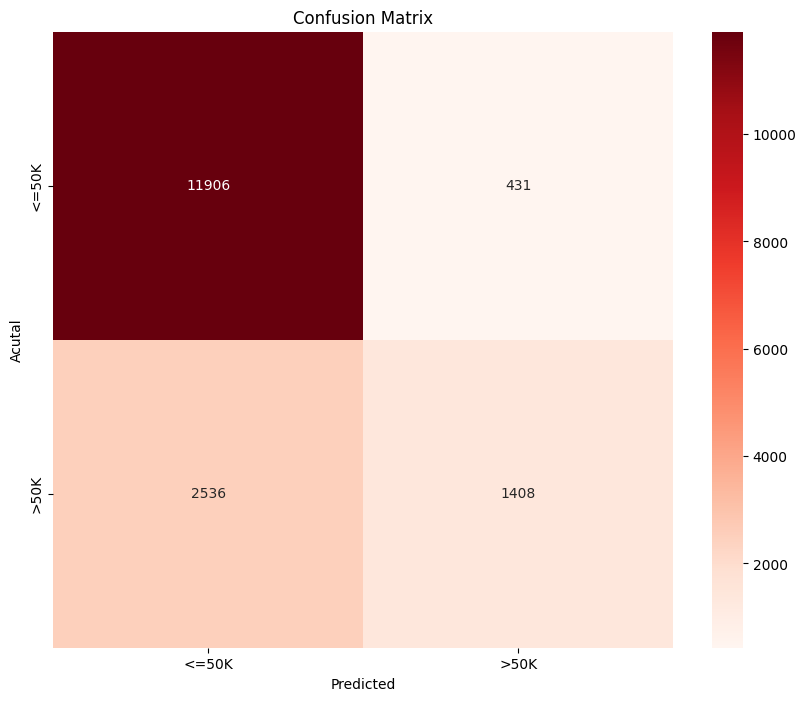

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.82      0.97      0.89     12337
        >50K       0.77      0.36      0.49      3944

    accuracy                           0.82     16281
   macro avg       0.80      0.66      0.69     16281
weighted avg       0.81      0.82      0.79     16281



In [65]:
# Accuracy score
print(f"Accuracy: {accuracy_score(test_label, test_prediction)}")

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(test_label, test_prediction)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['<=50K','>50K'],
            yticklabels=['<=50K','>50K'])
plt.xlabel('Predicted')
plt.ylabel('Acutal')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(test_label, test_prediction, target_names=['<=50K','>50K']))

### Unseen categories

In [66]:
for feature in categorical_features:
  print(feature)

workclass
education
marital-status
occupation
relationship
race
sex
native-country


## 3. Extending the model with semi-supervised training

### Option 3: Expectation-Maximisation (EM)

In [67]:
adult_unlabelled_data = pd.read_csv('Assignment1_data/adult_unlabelled.csv', sep=',')
adult_unlabelled_data = adult_unlabelled_data.dropna()

#### 1. Splitting dataset for EM training and validation

In [68]:
X_con_train_em, X_con_val_em, y_train_em, y_val_em = train_test_split(X_train_con, y_train, test_size=0.2)
X_cat_train_em, X_cat_val_em = train_test_split(X_train_cat_encoded, test_size=0.2)

#### 2. EM algorithm

[0.88268672 0.11731328]


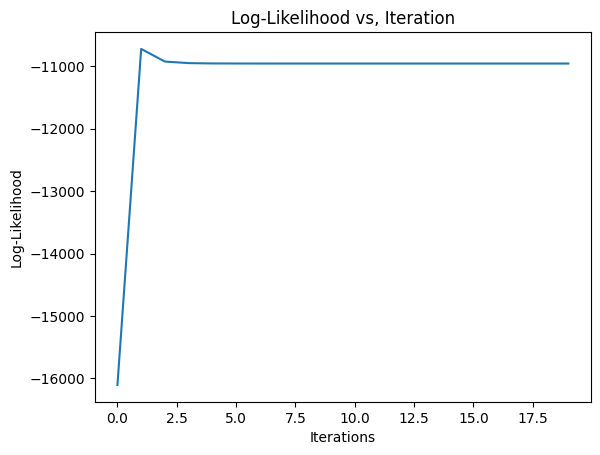

In [69]:
unlabelled_continuous_features = adult_unlabelled_data[['age','education-num','capital-gain','capital-loss','hours-per-week']]
unlabelled_categorical_features = adult_unlabelled_data[['workclass','education','marital-status','occupation','relationship','race','sex','native-country']]
unlabelled_categorical_features_encoded = categorical_encoder.transform(unlabelled_categorical_features)

class_priors = gaussian_nb.class_prior_
iterations = 20
log_likelihoods = []

# running em until covergence (fixed iterations = 10)
for iteration in range(iterations):
  
  # E-step: soft class assignments for each unlabelled instance
  continuous_log_prob = gaussian_nb.predict_log_proba(unlabelled_continuous_features)
  categorical_log_prob = categorical_nb.predict_log_proba(unlabelled_categorical_features_encoded)
  mixed_log_prob = continuous_log_prob + categorical_log_prob
  joint_log_prob = mixed_log_prob + np.log(class_priors)

  max_log = np.max(joint_log_prob, axis=1, keepdims=True)
  prob = np.exp(joint_log_prob - max_log)
  pos_prob = prob / np.sum(prob, axis=1, keepdims=True)

  log_likelihood = np.sum(
    np.log(np.sum(np.exp(joint_log_prob - max_log), axis=1)) + max_log.ravel()
  )
  log_likelihoods.append(log_likelihood)

  # M-step: retraining model with labelled and unlabelled data
  # Combined labelled and unlabelled data
  X_all_con = pd.concat([X_con_train_em, unlabelled_continuous_features])
  X_all_cat = np.vstack([X_cat_train_em, unlabelled_categorical_features_encoded]) 

  # labels
  y_labels = np.concatenate([y_train_em.values.ravel(), ['<=50K'] * len(unlabelled_continuous_features)])

  # weights: labelled data = 1, unlabelled data = soft assignments (posterior probabilities)
  weights = np.concatenate([np.ones(len(X_con_train_em)), pos_prob[:, 0]])

  # re-fit with weights
  gaussian_nb.fit(X_all_con, y_labels, sample_weight=weights)
  categorical_nb.fit(X_all_cat, y_labels, sample_weight=weights)
  class_priors = gaussian_nb.class_prior_

print(class_priors)
plt.plot(log_likelihoods)
plt.xlabel('Iterations')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs, Iteration')
plt.show()


#### 3. EM validation set evaluation

In [70]:
val_prob_con = gaussian_nb.predict_log_proba(X_con_val_em)
val_prob_cat = categorical_nb.predict_log_proba(X_cat_val_em)

val_joint_prob = val_prob_con + val_prob_cat + np.log(class_priors)
y_val_prediction = np.argmax(val_joint_prob, axis=1)
y_val_em = label_encoder.transform(y_val_em)

print(f"Accuracy: {accuracy_score(y_val_em, y_val_prediction)}")


Accuracy: 0.7894562334217506


## 4. Semi-supervised model evaluation

### Test prediction

In [71]:
test_continuous_prob_em = gaussian_nb.predict_log_proba(test_continuous_features)
test_categorical_prob_em = categorical_nb.predict_log_proba(test_categorical_features_encoded)

test_joint_log_prob_em = test_continuous_prob_em + test_categorical_prob_em + np.log(class_priors)
test_prediction_em = np.argmax(test_joint_log_prob_em, axis=1)

### Classification report

Accuracy: 0.7945457895706652
Confusion Matrix:


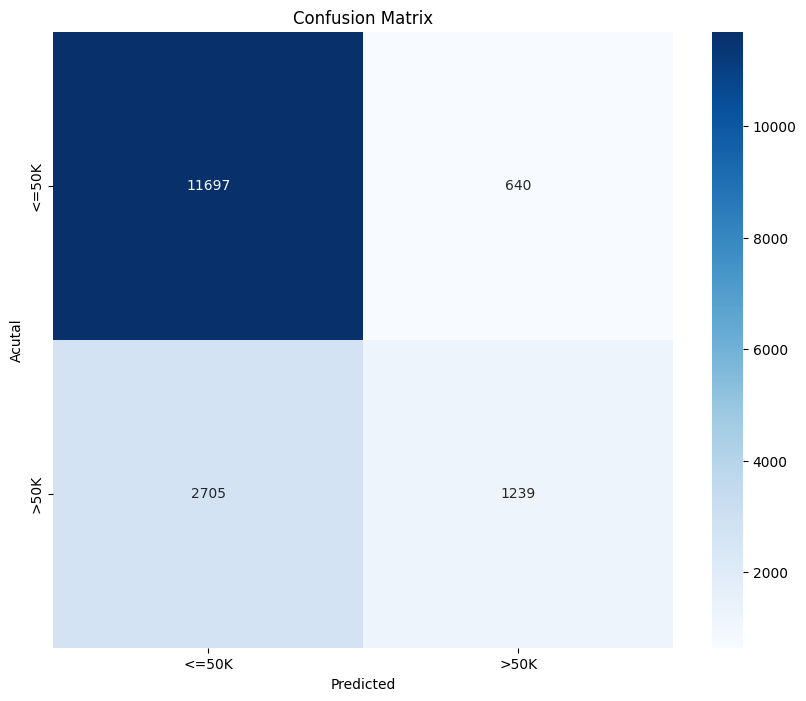

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.81      0.95      0.87     12337
        >50K       0.66      0.31      0.43      3944

    accuracy                           0.79     16281
   macro avg       0.74      0.63      0.65     16281
weighted avg       0.78      0.79      0.77     16281



In [72]:
# Accuracy score
print(f"Accuracy: {accuracy_score(test_label, test_prediction_em)}")

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(test_label, test_prediction_em)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K','>50K'],
            yticklabels=['<=50K','>50K'])
plt.xlabel('Predicted')
plt.ylabel('Acutal')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(test_label, test_prediction_em, target_names=['<=50K','>50K']))